In [4]:
# SQ4: Cross-Positional Attention (XPA) Extension
import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss
import random

# Import your existing pipeline
sys.path.append(os.path.abspath('..'))
from src.data_preprocessing import get_behavioral_datasets
from src.data_preprocessing import get_modeling_datasets

def set_deep_learning_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_deep_learning_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
class SessionSequenceDataset(Dataset):
    def __init__(self, df, max_seq_length=20):
        self.sessions = []
        
        # Group by the unique search event
        grouped = df.groupby('search_idx')
        
        for _, group in grouped:
            # Sort by position to maintain the physical layout order
            group = group.sort_values('position')
            
            positions = group['position'].values
            is_left = group['is_left_column'].values.astype(float)
            clicks = group['click'].values.astype(float)
            
            # Truncate if the session exceeds max_seq_length
            if len(positions) > max_seq_length:
                positions = positions[:max_seq_length]
                is_left = is_left[:max_seq_length]
                clicks = clicks[:max_seq_length]
                
            seq_len = len(positions)
            pad_len = max_seq_length - seq_len
            
            # Mask: 1 (True) for real items, 0 (False) for empty padding space
            mask = np.ones(max_seq_length)
            mask[seq_len:] = 0 
            
            pos_padded = np.pad(positions, (0, pad_len), 'constant', constant_values=0)
            left_padded = np.pad(is_left, (0, pad_len), 'constant', constant_values=0)
            clicks_padded = np.pad(clicks, (0, pad_len), 'constant', constant_values=0)
            
            self.sessions.append({
                'positions': torch.tensor(pos_padded, dtype=torch.long),
                'is_left': torch.tensor(left_padded, dtype=torch.float),
                'clicks': torch.tensor(clicks_padded, dtype=torch.float),
                'mask': torch.tensor(mask, dtype=torch.bool)
            })
            
    def __len__(self):
        return len(self.sessions)
    
    def __getitem__(self, idx):
        return self.sessions[idx]

print("Loading datasets...")
train_df, test_df, dqa_df = get_modeling_datasets()

print("Building sequence datasets (this may take a minute)...")
train_dataset = SessionSequenceDataset(train_df, max_seq_length=20)
test_dataset = SessionSequenceDataset(test_df, max_seq_length=20)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train sessions: {len(train_dataset)} | Test sessions: {len(test_dataset)}")

Loading datasets...
Downloading/Loading Qilin from HuggingFace...


Flattening modeling splits to impression level...
Building sequence datasets (this may take a minute)...
Train sessions: 44024 | Test sessions: 6192


In [6]:
class XPAModel(nn.Module):
    def __init__(self, max_position=50, embed_dim=8, num_heads=2):
        super(XPAModel, self).__init__()
        
        # 1. Embeddings for layout elements
        self.pos_embedding = nn.Embedding(num_embeddings=max_position + 1, embedding_dim=embed_dim)
        self.col_embedding = nn.Linear(1, embed_dim) 
        
        # 2. The Context Engine (Self-Attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=32, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        # 3. Examination output mapping
        self.exam_mlp = nn.Sequential(
            nn.Linear(embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
        # 4. Relevance Pathway (Identical to PAL constraint)
        self.global_relevance = nn.Parameter(torch.tensor([0.0]))

    def forward(self, positions, is_left, mask):
        # Create Layout Embeddings
        pos_emb = self.pos_embedding(positions) # [batch, seq_len, embed_dim]
        col_emb = self.col_embedding(is_left.unsqueeze(-1)) # [batch, seq_len, embed_dim]
        
        layout_features = pos_emb + col_emb 
        
        # PyTorch requires True for elements that should be IGNORED by attention
        # Because our mask is True for valid items, we invert it (~)
        padding_mask = ~mask 
        
        # Cross-Positional Attention calculation
        attended_features = self.transformer(layout_features, src_key_padding_mask=padding_mask)
        
        # Calculate final probabilities
        prob_examine = self.exam_mlp(attended_features).squeeze(-1)
        prob_relevance = torch.sigmoid(self.global_relevance)
        
        prob_click = prob_examine * prob_relevance
        
        return prob_click, prob_examine

In [7]:
def train_xpa(model, train_loader, epochs=10, lr=0.005):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        
        for batch in train_loader:
            positions = batch['positions'].to(device)
            is_left = batch['is_left'].to(device)
            clicks = batch['clicks'].to(device)
            mask = batch['mask'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            prob_click, _ = model(positions, is_left, mask)
            
            # Flatten outputs and apply mask to ignore padding calculations
            active_probs = prob_click[mask]
            active_clicks = clicks[mask]
            
            # Calculate loss strictly on actual visible items
            loss = criterion(active_probs, active_clicks)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_loss:.4f}")
        
    return model

# Initialize and train
xpa_model = XPAModel(max_position=100, embed_dim=8, num_heads=2).to(device)
print("Starting XPA Training...")
xpa_model = train_xpa(xpa_model, train_loader, epochs=10, lr=0.005)

Starting XPA Training...
Epoch [1/10] | Train Loss: 0.5283
Epoch [2/10] | Train Loss: 0.5199
Epoch [3/10] | Train Loss: 0.5186
Epoch [4/10] | Train Loss: 0.5175
Epoch [5/10] | Train Loss: 0.5170
Epoch [6/10] | Train Loss: 0.5167
Epoch [7/10] | Train Loss: 0.5167
Epoch [8/10] | Train Loss: 0.5165
Epoch [9/10] | Train Loss: 0.5163
Epoch [10/10] | Train Loss: 0.5164


In [8]:
def evaluate_xpa(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            positions = batch['positions'].to(device)
            is_left = batch['is_left'].to(device)
            clicks = batch['clicks'].to(device)
            mask = batch['mask'].to(device)
            
            prob_click, _ = model(positions, is_left, mask)
            
            # Extract only valid non-padded items for evaluation
            active_probs = prob_click[mask]
            active_clicks = clicks[mask]
            
            all_preds.extend(active_probs.cpu().numpy())
            all_targets.extend(active_clicks.cpu().numpy())
            
    auc = roc_auc_score(all_targets, all_preds)
    loss = log_loss(all_targets, all_preds)
    
    print(f"\n--- XPA Model Evaluation (Standard Baseline Data) ---")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"LogLoss: {loss:.4f}")
    
    return auc, loss

evaluate_xpa(xpa_model, test_loader)

c:\Users\kooij\Desktop\DS_Master\Thesis\Thesis_masters\.venv\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(



--- XPA Model Evaluation (Standard Baseline Data) ---
ROC-AUC: 0.6724
LogLoss: 0.5257


(0.672378938265627, 0.5256823541254105)

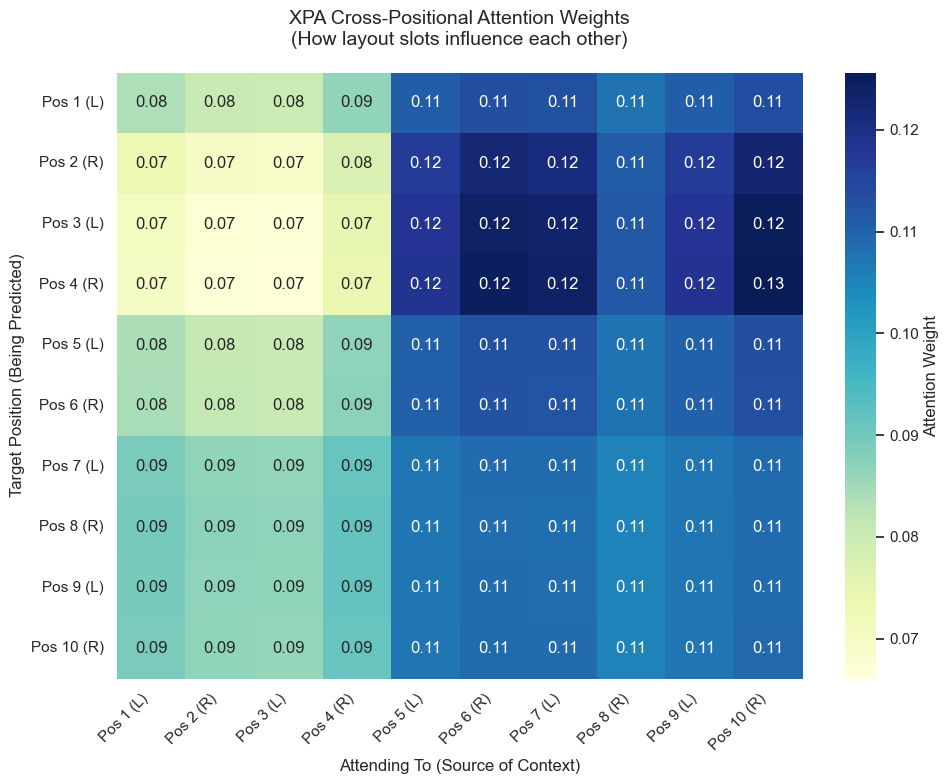

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def extract_and_plot_attention(model):
    model.eval()
    
    # 1. Simulate a standard 10-item two-column layout session
    # Positions 1 through 10
    positions = torch.tensor([list(range(1, 11))], dtype=torch.long).to(device)
    
    # Alternating columns: 1=Left, 0=Right
    is_left = torch.tensor([[1, 0, 1, 0, 1, 0, 1, 0, 1, 0]], dtype=torch.float).to(device)
    
    # All items are valid (no padding)
    mask = torch.tensor([[True] * 10], dtype=torch.bool).to(device)
    
    with torch.no_grad():
        # 2. Pass through the embedding layers
        pos_emb = model.pos_embedding(positions)
        col_emb = model.col_embedding(is_left.unsqueeze(-1))
        layout_features = pos_emb + col_emb
        
        # 3. Pytorch Trick: Access the Multi-Head Attention module directly 
        # inside the Transformer Encoder to force it to return the weights
        mha = model.transformer.layers[0].self_attn
        
        # Invert mask for PyTorch's padding logic (False means 'do not ignore')
        padding_mask = ~mask
        
        # Extract the attention weights (need_weights=True is the key here)
        _, attn_weights = mha(
            query=layout_features, 
            key=layout_features, 
            value=layout_features, 
            key_padding_mask=padding_mask,
            need_weights=True
        )
        
    # 4. Plot the Heatmap
    # attn_weights shape is [batch_size, seq_len, seq_len]. We take the first batch.
    attention_matrix = attn_weights[0].cpu().numpy()
    
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="white")
    
    # Create descriptive labels (e.g., "Pos 1 (L)", "Pos 2 (R)")
    labels = [f"Pos {i} ({'L' if i%2!=0 else 'R'})" for i in range(1, 11)]
    
    sns.heatmap(
        attention_matrix, 
        cmap="YlGnBu", 
        annot=True, 
        fmt=".2f", 
        cbar_kws={'label': 'Attention Weight'},
        xticklabels=labels,
        yticklabels=labels
    )
    
    plt.title("XPA Cross-Positional Attention Weights\n(How layout slots influence each other)", fontsize=14, pad=20)
    plt.xlabel("Attending To (Source of Context)", fontsize=12)
    plt.ylabel("Target Position (Being Predicted)", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig('Fig_5_xpa_attention_heatmap.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the visualizer
extract_and_plot_attention(xpa_model)

XPA model successfully saved to 'best_xpa_model.pth'
Generating final predictions for ROC curve...


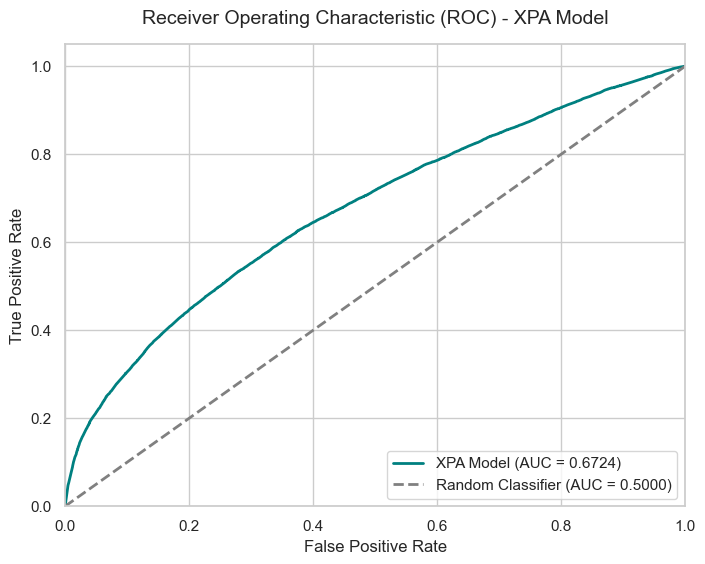

In [10]:
from sklearn.metrics import roc_curve, auc

# 1. Save the model weights
torch.save(xpa_model.state_dict(), 'best_xpa_model.pth')
print("XPA model successfully saved to 'best_xpa_model.pth'")

def plot_xpa_roc(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    print("Generating final predictions for ROC curve...")
    with torch.no_grad():
        for batch in test_loader:
            positions = batch['positions'].to(device)
            is_left = batch['is_left'].to(device)
            clicks = batch['clicks'].to(device)
            mask = batch['mask'].to(device)
            
            prob_click, _ = model(positions, is_left, mask)
            
            active_probs = prob_click[mask]
            active_clicks = clicks[mask]
            
            all_preds.extend(active_probs.cpu().numpy())
            all_targets.extend(active_clicks.cpu().numpy())
            
    # 2. Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
    roc_auc = auc(fpr, tpr)
    
    # 3. Plot the curve
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="whitegrid")
    
    plt.plot(fpr, tpr, color='#008080', lw=2, label=f'XPA Model (AUC = {roc_auc:.4f})')
    
    # Plot the random chance baseline
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) - XPA Model', fontsize=14, pad=15)
    plt.legend(loc="lower right", fontsize=11)
    
    plt.savefig('Fig_6_xpa_roc_curve.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the plotter
plot_xpa_roc(xpa_model, test_loader)